In [86]:
from IPython.core.magic import register_cell_magic

@register_cell_magic
def skip(line, cell):
    print("skip cell")
    return

In [13]:
from influxdb_client import InfluxDBClient
from influxdb_client.client.exceptions import InfluxDBError

import datetime
import os, csv
import pandas as pd
import numpy as np

os.system('cls')

root_folder = r"C:\Develop\py\FluidicsLab\Drafts\report"
config_folder = os.path.join(root_folder, "config")

dest_folder = os.path.join(root_folder, "reports")
data_folder = os.path.join(root_folder, "data")

connection_file = os.path.join(config_folder, "connection.ini")

# ---------------------------------------------------------------------------------------------------
# duration

_delay = 18

_stop = datetime.datetime.now()
_start = _stop - datetime.timedelta(hours=_delay)

# ---------------------------------------------------------------------------------------------------

application = "eit heating 04"
filename = "report.1"

prefix = f"{_delay}_{application}"

print(f"--- {prefix} {application}")
print(f"    query {_start} {_stop}")

# ---------------------------------------------------------------------------------------------------
# query

print(f"--- query database")

param = {
    "_start": _start,
    "_stop": _stop, 
    "_every": datetime.timedelta(seconds=1),
    "_unit": datetime.timedelta(milliseconds=1),
    "_name": ""
}

db_query = {

    'HC40':

    'from(bucket: "data") \
    |> range(start: time(v: "2025-10-18T11:00:00.000Z"), stop: time(v: "2025-10-19T01:00:00.000Z")) \
    |> filter(fn: (r) => r["_measurement"] == "app") \
    |> filter(fn: (r) => r["tag"] == "heating" or r["tag"] == "cooling") \
    |> filter(fn: (r) => r["addr"] == "4" or r["addr"] == "1") \
    |> filter(fn: (r) => r["_field"] == "value") \
    |> aggregateWindow(every: 1s, fn: mean, createEmpty: false)   \
    |> map(fn: (r) => ({ r with _field: r.tag + "_" + r.addr })) \
    |> keep(columns: ["_time", "_field", "_value"]) \
    |> pivot(rowKey: ["_time"], columnKey: ["_field"], valueColumn: "_value") \
    |> map(fn: (r) => ({ r with _time: int(v: r._time) })) \
    |> fill(column: "cooling_1", value: 0.0) \
    |> fill(column: "heating_4", value: 0.0)',
    
}

db_data = {}
data_file = {}

client = None
try:

    client = InfluxDBClient.from_config_file(connection_file)

    for name in db_query.keys():
        
        print(f"--- query {name}")
        param["_name"] = name

        db_data[name] = client.query_api().query_csv(db_query[name], params=param).to_values()   
        
        print(f'    {name}: {len(db_data[name])} entries')

        data_file[name] = os.path.join(data_folder, f"{prefix}_{filename}_{name}.csv")
        print(f'    write {data_file[name]}')
        with open(data_file[name], 'w', newline='') as f:
            w = csv.writer(f, quoting=csv.QUOTE_NONNUMERIC)
            w.writerows(db_data[name])

except InfluxDBError as ixe:
    print(f"    ERROR(InfluxDBError) {ixe}")
except Exception as ex:
    print(f"    ERROR(Exception) {ex}")
finally:
    if client is not None:
        client.close()

--- 18_eit heating 04 eit heating 04
    query 2025-10-18 14:55:41.308331 2025-10-19 08:55:41.308331
--- query database
--- query HC40
    HC40: 50404 entries
    write C:\Develop\py\FluidicsLab\Drafts\report\data\18_eit heating 04_report.1_HC40.csv


In [14]:
# preparation

data = {}

data_cols = {    
    "HC40": ["_time","heating_4","cooling_1"]
}

for name in data_file.keys():
    
    data[name] = pd.read_csv(data_file[name], skiprows=[0,1,2], usecols=data_cols[name])

    print(f'    read {data_file[name]} as {data[name].shape}')
    print(f'    {data[name].columns}')

    read C:\Develop\py\FluidicsLab\Drafts\report\data\18_eit heating 04_report.1_HC40.csv as (50400, 3)
    Index(['_time', 'cooling_1', 'heating_4'], dtype='object')


In [16]:
name = "HC40"

frame = data[name]

for col in data_cols["HC40"][1:]:
    frame.loc[:,(col)] = frame.loc[:,(col)].astype(float)

pd.DataFrame.to_csv(frame, f"{data_file[name]}.csv", sep=";", index=None)

frame.describe()

,_time,cooling_1,heating_4
count,5.040000e+04,50400.000000,50400.000000
mean,1.760810e+18,44.212472,90.416301
std,1.454937e+13,6.876922,48.204609
min,1.760785e+18,24.100000,0.000000
25%,1.760798e+18,46.000000,114.700000
50%,1.760810e+18,47.300000,116.000000
75%,1.760823e+18,47.800000,116.200000
max,1.760836e+18,48.600000,121.500000


In [ ]:

# time [min]

t = frame["_time"].to_numpy()
t = (t - t[0]).astype(np.float64) / 1e9 / 60

H = frame["heating_4"].to_numpy()
C = frame["cooling_1"].to_numpy()


    using style seaborn-v0_8-dark-palette
    using 120 dpi
    write C:\Develop\py\FluidicsLab\Drafts\report\data\18_eit heating 04_report.1_ft.png


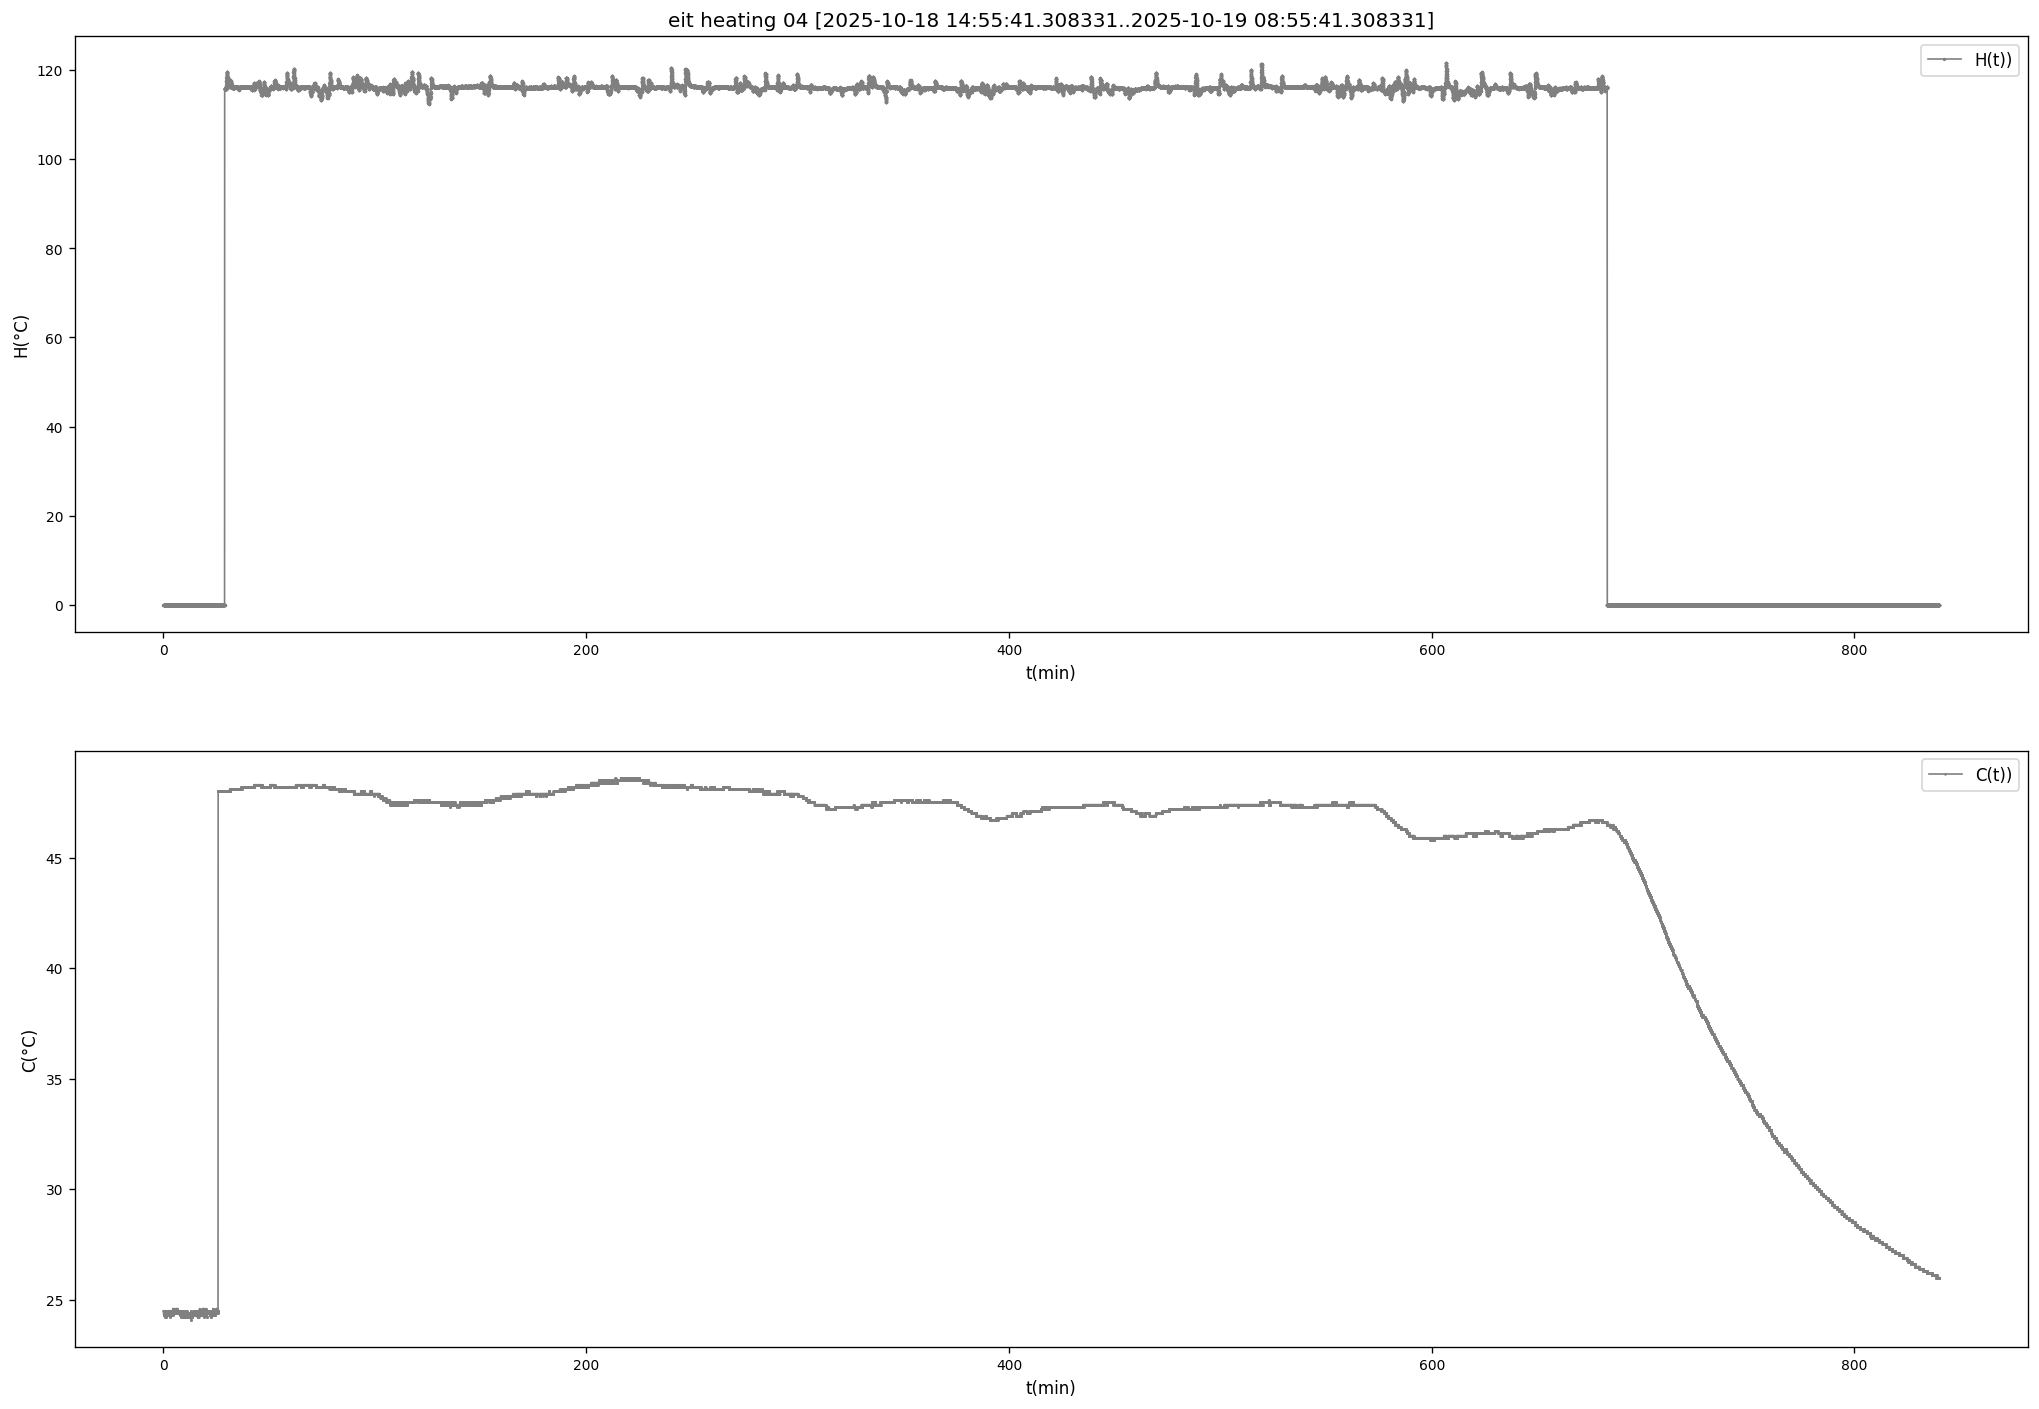

In [18]:
import matplotlib as mpl
from matplotlib import pyplot as plt

# plot the data set P(t), T(t)

style = "seaborn-v0_8-dark-palette"
print(f"    using style {style}")
plt.style.use(style)

mpl.rcParams['xtick.labelsize'] = 'small'
mpl.rcParams['ytick.labelsize'] = 'small'

fig, ax = plt.subplots(2,1)
fig.set_size_inches(21,14)

dpi = 120
print(f"    using {dpi} dpi")
fig.set_dpi(dpi)

ax[0].plot(t, H,'.-', ms=2., lw=1., color='grey', label=f"H(t))")

ax[0].set_xlabel("t(min)")
ax[0].set_ylabel("H(°C)")
ax[0].legend()

ax[1].plot(t, C,'.-', ms=1., lw=1., color='grey', label=f"C(t))")

ax[1].set_xlabel("t(min)")
ax[1].set_ylabel("C(°C)")
ax[1].legend()

ax[0].set_title(f"{application} [{_start}..{_stop}]")
plt.subplots_adjust(bottom=0.1)


plot_file = os.path.join(data_folder, f"{prefix}_{filename}_ft.png")
if os.path.exists(plot_file):
    os.remove(plot_file)

print(f"    write {plot_file}")
plt.savefig(plot_file, dpi=dpi, facecolor='w')

plt.show()


    using style seaborn-v0_8-dark-palette
    using 120 dpi
    write C:\Develop\py\FluidicsLab\Drafts\report\data\18_eit heating 04_report.1.png


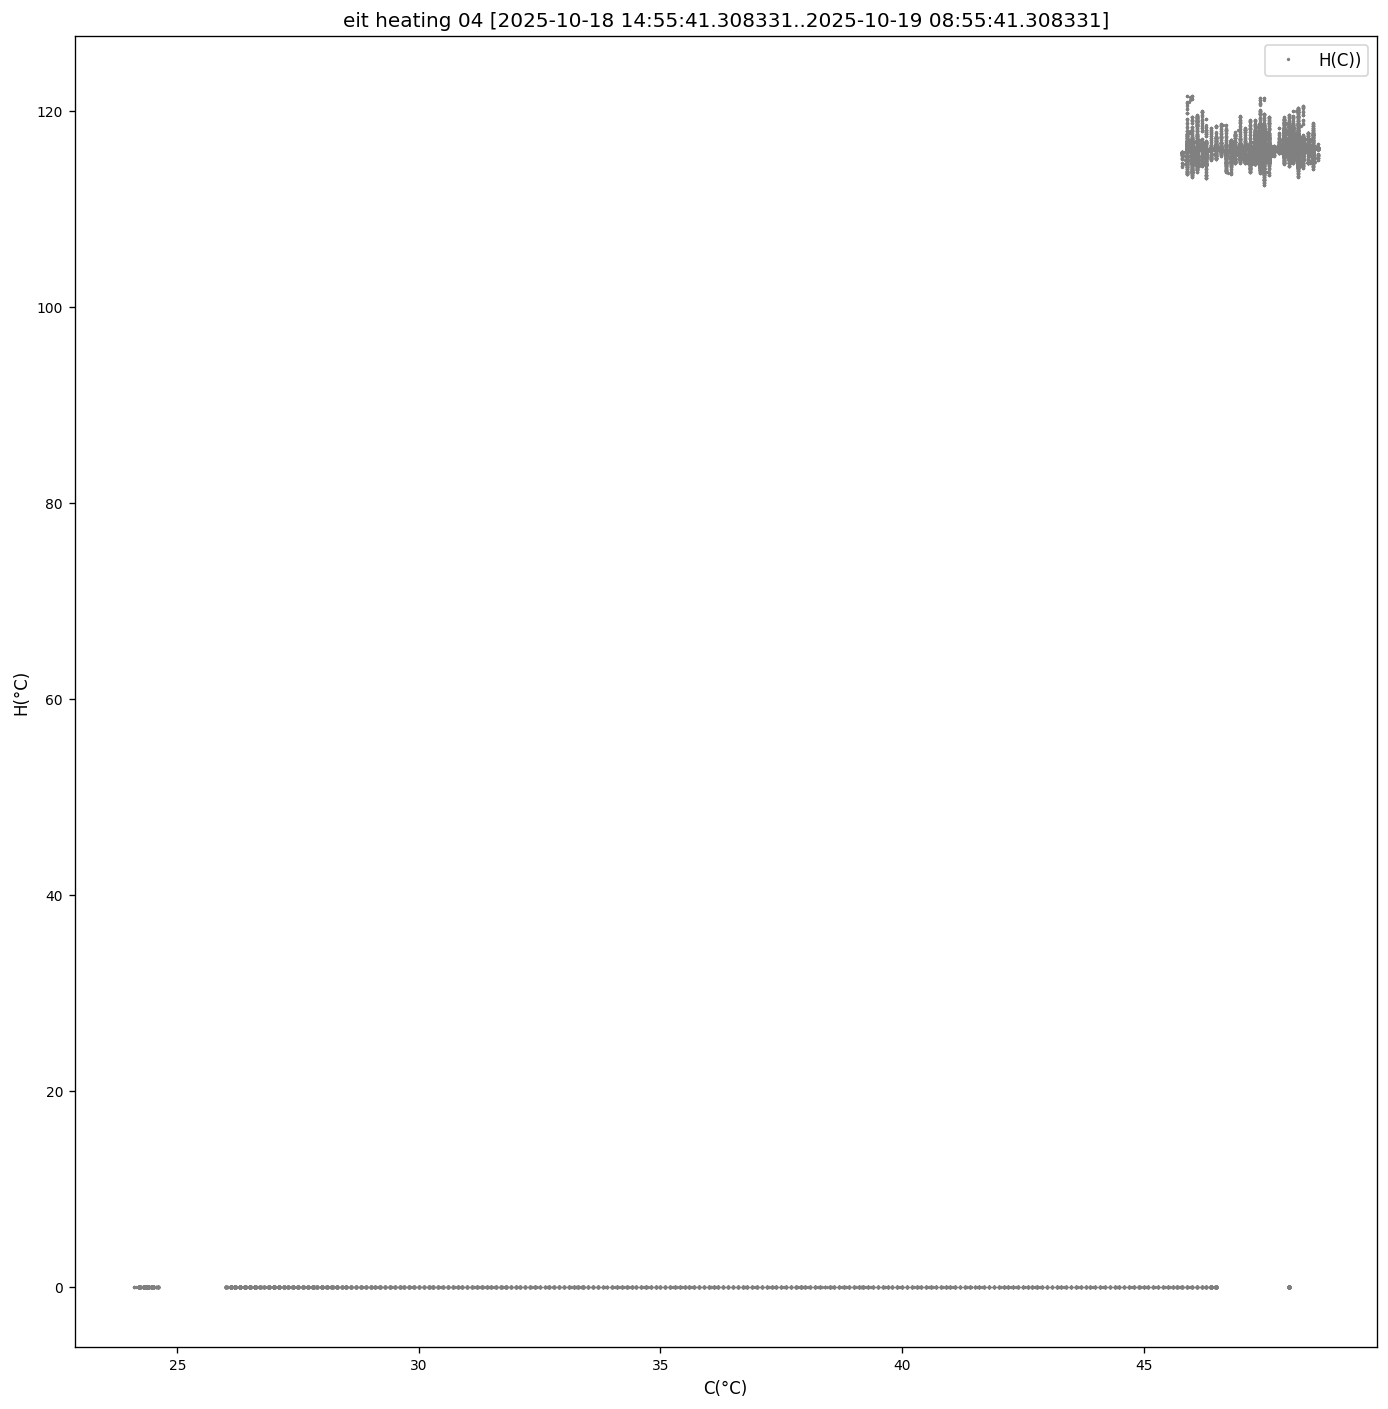

In [20]:

# plot the data set P(T)

style = "seaborn-v0_8-dark-palette"
print(f"    using style {style}")
plt.style.use(style)

mpl.rcParams['xtick.labelsize'] = 'small'
mpl.rcParams['ytick.labelsize'] = 'small'

fig, ax = plt.subplots(1,1)
fig.set_size_inches(14,14)

dpi = 120
print(f"    using {dpi} dpi")
fig.set_dpi(dpi)

ax.plot(C, H,'.', ms=2., lw=1., color='grey', label=f"H(C))")

ax.set_xlabel("C(°C)")
ax.set_ylabel("H(°C)")

ax.set_title(f"{application} [{_start}..{_stop}]")
plt.subplots_adjust(bottom=0.1)

plt.legend()

plot_file = os.path.join(data_folder, f"{prefix}_{filename}.png")
if os.path.exists(plot_file):
    os.remove(plot_file)

print(f"    write {plot_file}")
plt.savefig(plot_file, dpi=dpi, facecolor='w')

plt.show()